In [27]:
# Gerando modelo de Machine Learning (classificação)
# Domínio: Pessoas com doença de Verrugas e tratamento com Crioterapia.
# Ricardo Roberto de Lima
# Aluno: Max Cavalcante (commitado)

In [28]:
#Conjunto de importacoes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [29]:
import os
from IPython.display import Image, display

if os.path.exists('Workflow.png'):
    display(Image('Workflow.png'))
else:
    print("Imagem 'Workflow.png' nao encontrada nesta pasta (arquivo ilustrativo, opcional).")

Imagem 'Workflow.png' nao encontrada nesta pasta (arquivo ilustrativo, opcional).


In [30]:
# Foi colocado um aviso caso não encontre a imagem (a imagem não foi disponibilizada)

In [31]:
#Carrega o dataset com os dados para o treinamento e validacao
df_crioterapia_treino = pd.read_csv("dados_cryotherapy.csv", encoding="utf-8")

In [32]:
df_crioterapia_treino.describe()

,Sexo,Idade,Tempo,Numero_Verrugas,Tipo,Area,Resultado_Tratamento
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,1.477778,28.600000,7.344444,5.511111,1.700000,85.833333,0.533333
std,0.502304,13.360852,3.379253,3.567155,0.905042,131.733153,0.501683
min,1.000000,15.000000,1.000000,1.000000,1.000000,4.000000,0.000000
25%,1.000000,18.000000,4.000000,2.000000,1.000000,20.000000,0.000000
50%,1.000000,25.500000,8.000000,5.000000,1.000000,70.000000,1.000000
75%,2.000000,35.000000,10.000000,8.000000,3.000000,100.000000,1.000000
max,2.000000,67.000000,12.000000,12.000000,3.000000,750.000000,1.000000


In [33]:
# Verificando o formato dos dados
df_crioterapia_treino.shape

(90, 7)

In [34]:
#Definição dos atributos que deverao ser treinados para gerar o modelo de classificacao
data_treino = np.array(df_crioterapia_treino[['Sexo', 'Idade', 'Numero_Verrugas', 'Tipo', 'Area']])
#Definição do atributo de classificacao
data_classif = np.array(df_crioterapia_treino['Resultado_Tratamento'])

In [35]:
# Verificando as primeiras linhas do dataset
df_crioterapia_treino.head(5)

,Sexo,Idade,Tempo,Numero_Verrugas,Tipo,Area,Resultado_Tratamento
0,1,35,12,5,1,100,0
1,1,29,7,5,1,96,1
2,1,50,8,1,3,132,0
3,1,32,11,7,3,750,0
4,1,67,9,1,1,42,0


In [36]:
# Verificando as ultimas linhas do dataset
df_crioterapia_treino.tail(5)

,Sexo,Idade,Tempo,Numero_Verrugas,Tipo,Area,Resultado_Tratamento
85,2,34,12,3,3,95,0
86,2,20,3,6,1,75,1
87,2,35,8,8,3,100,0
88,1,24,10,10,1,20,1
89,1,19,8,8,1,160,1


In [37]:
# Identificando a correlação entre as variáveis
# Correlação não implica causalidade
def plot_corr(df_crioterapia_treino, size=35):
    corr = df_crioterapia_treino.corr()
    fig, ax = plt.subplots(figsize = (size, size))
    ax.matshow(corr)
    plt.xticks(range(len(corr.columns)), corr.columns)
    plt.yticks(range(len(corr.columns)), corr.columns)


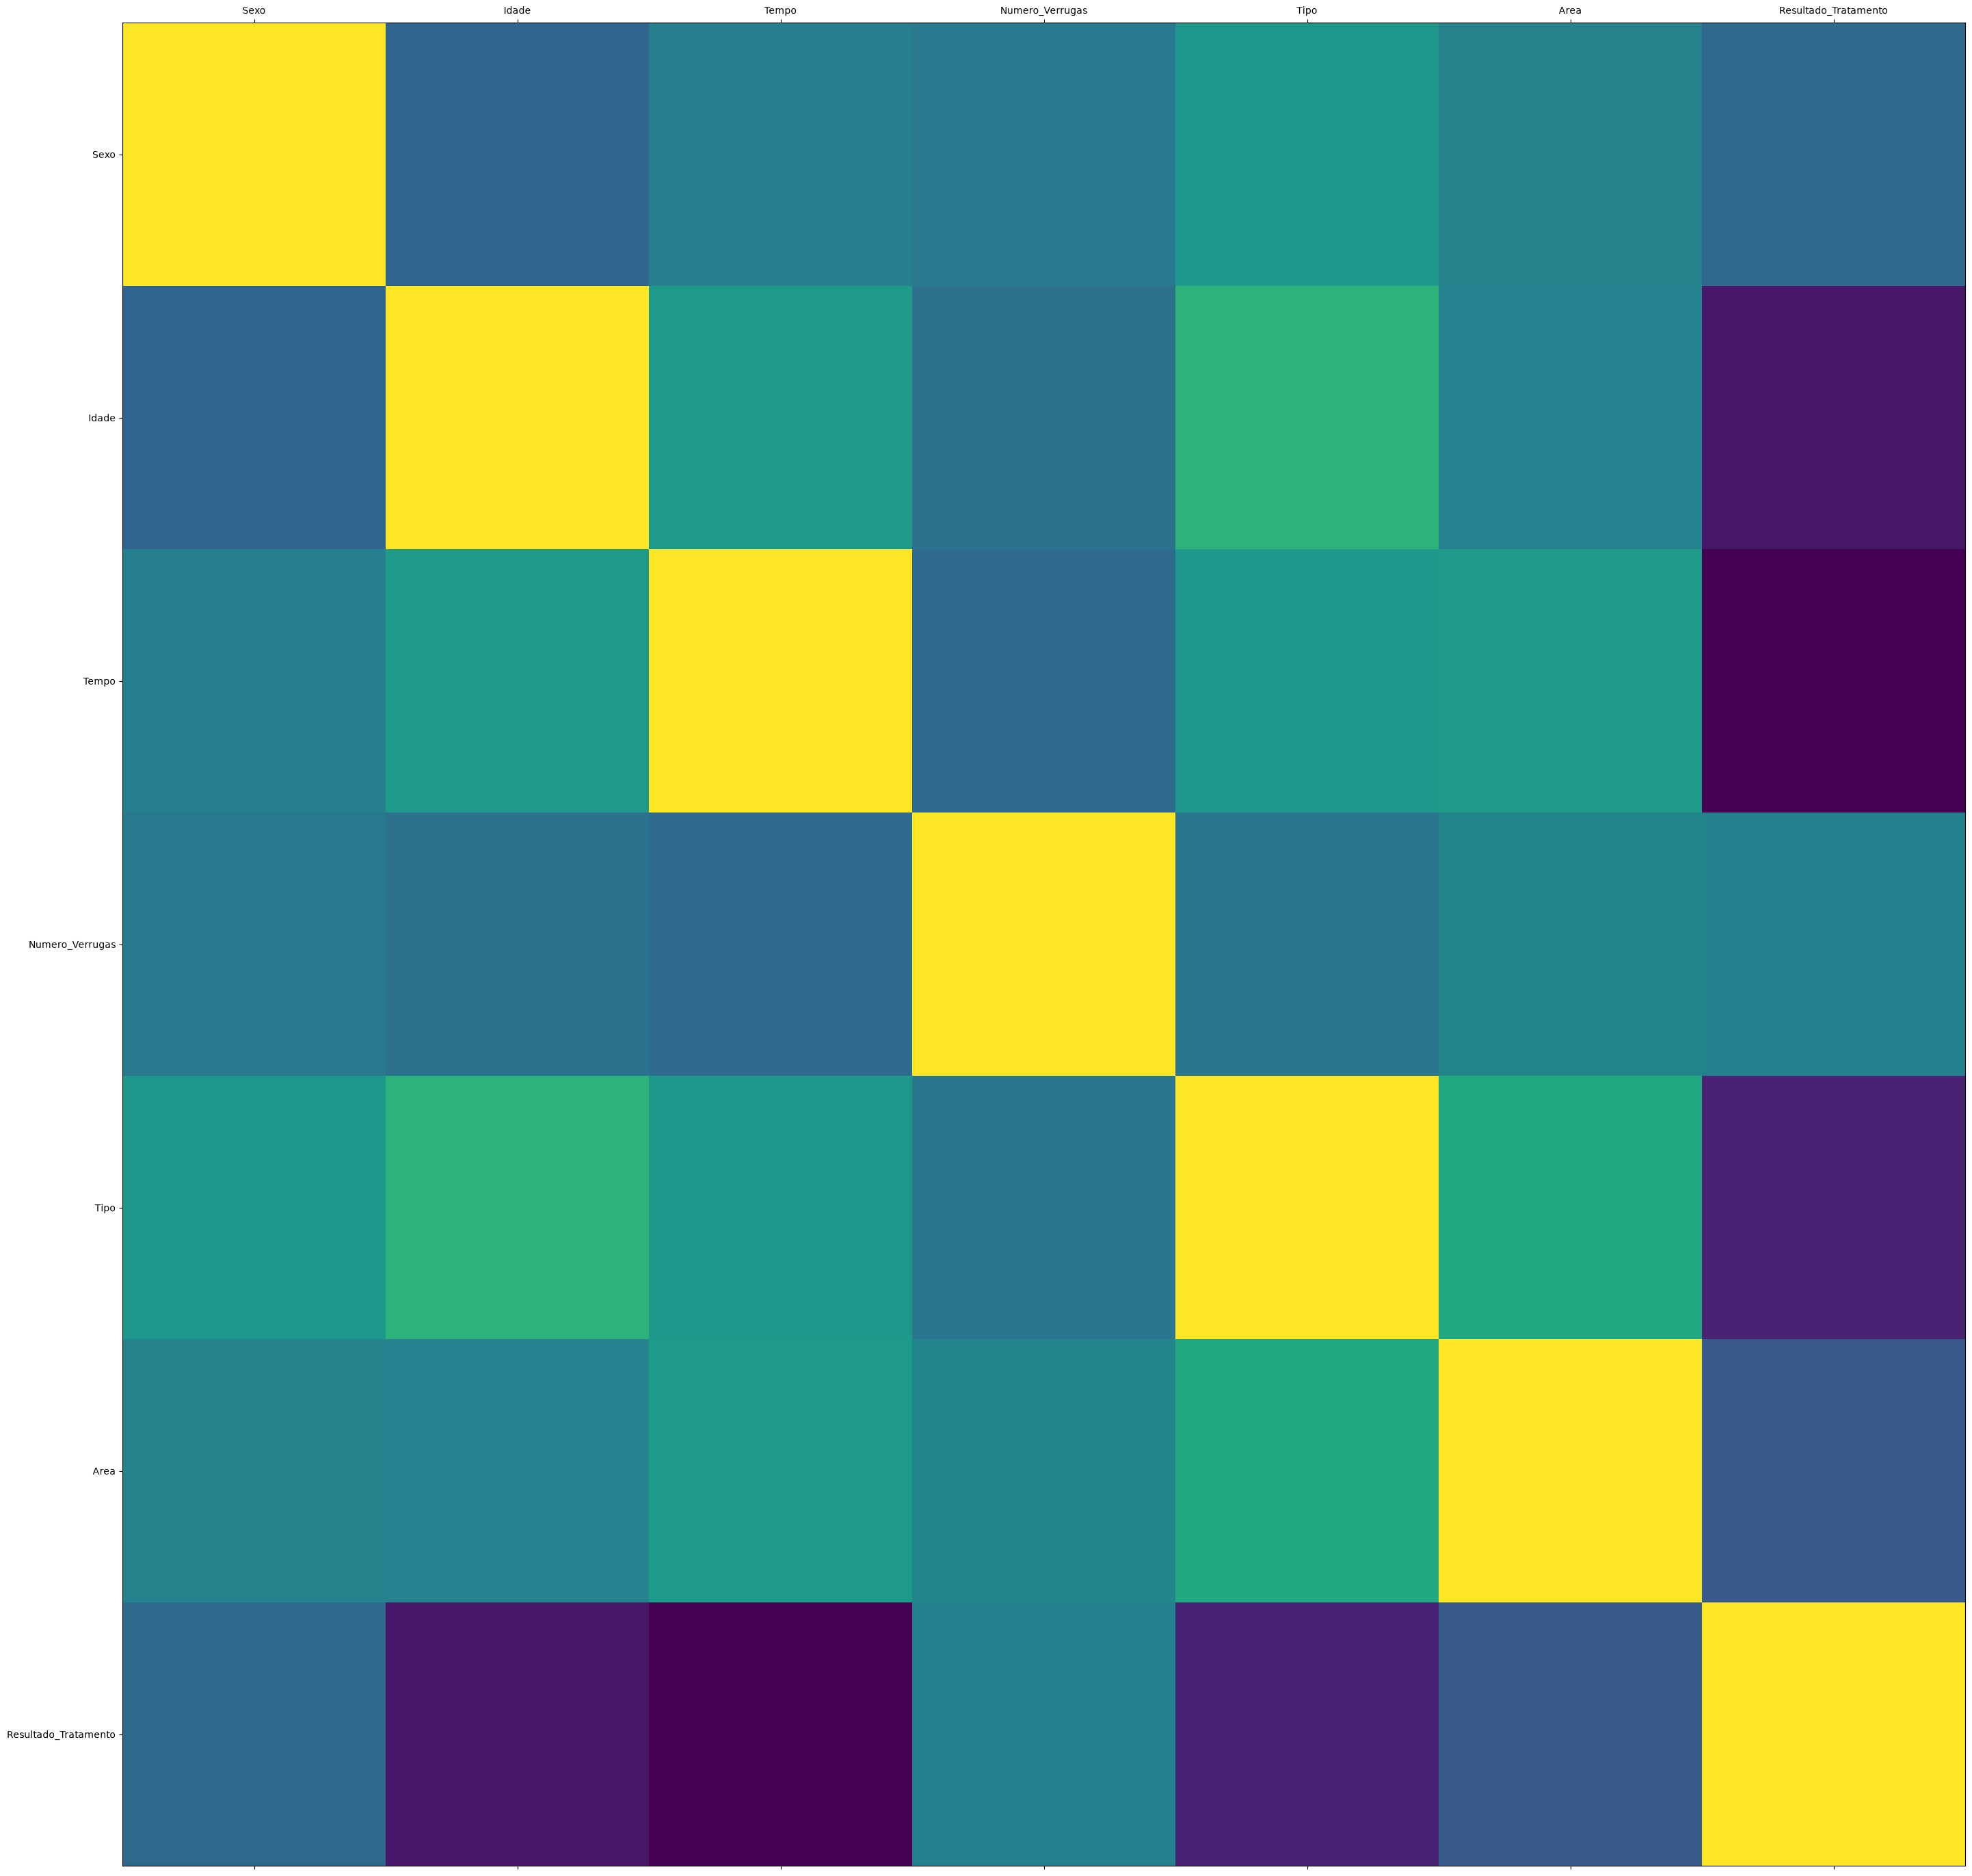

In [38]:
# Criando o gráfico - Matriz de Correlação..
plot_corr(df_crioterapia_treino)

In [39]:
# Spliting = 70% para dados de treino e 30% para dados de teste

In [40]:
import os
from IPython.display import Image, display

if os.path.exists('Treinamento.png'):
    display(Image('Treinamento.png'))
else:
    print("Imagem 'Treinamento.png' nao encontrada nesta pasta (arquivo ilustrativo, opcional).")

Imagem 'Treinamento.png' nao encontrada nesta pasta (arquivo ilustrativo, opcional).


In [41]:
# Foi colocado um aviso caso não encontre a imagem (a imagem não foi disponibilizada)

In [42]:
#Definição dos conjuntos de treinamento e validação
x_treino, x_val, y_treino, y_val = train_test_split(data_treino, data_classif, test_size=0.30)

In [43]:
#Apresentacao dos dados selecionados para o conjunto de treinamento e validacao
print("-----------------------")
print("Conjunto de Treinamento")
print(x_treino)
print("Conjunto de Validacao")
print(x_val)
print("-----------------------")

-----------------------
Conjunto de Treinamento
[[  1  20   3   1   6]
 [  1  17  10   1  63]
 [  2  22   2   1  70]
 [  1  15  11   1  30]
 [  1  29   5   1  96]
 [  2  35   6   3 100]
 [  2  36   6   1   8]
 [  2  17   2   1  10]
 [  2  16   1   2  60]
 [  1  22   2   1  70]
 [  1  63   3   3  20]
 [  2  41   2   2  20]
 [  2  15  10   3  70]
 [  1  15   5   1   6]
 [  1  15  11   1   4]
 [  2  50   4   3 132]
 [  2  32   4   3 750]
 [  1  36   2   1   8]
 [  1  32   7   3 750]
 [  1  15   7   1   6]
 [  1  35   9   1 100]
 [  2  18   1   1  80]
 [  2  28  11   1 100]
 [  1  50   1   3 132]
 [  2  21   5   1  35]
 [  1  67  11   3  20]
 [  1  20   2   1  75]
 [  2  35   8   3 100]
 [  2  15  12   3  70]
 [  2  41   5   2  20]
 [  1  23   7   3  72]
 [  1  18   1   1  80]
 [  2  67  12   3  42]
 [  1  17   4   1  63]
 [  2  15  12   1  30]
 [  2  24   3   3  20]
 [  1  50  11   3 132]
 [  1  67   1   1  42]
 [  1  34   1   3 150]
 [  1  35   5   1 100]
 [  1  40   9   2  80]
 [  2  18

In [44]:
# Imprimindo os resultados
print("{0:0.2f}% nos dados de treino".format((len(x_treino)/len(df_crioterapia_treino.index)) * 100))
print("{0:0.2f}% nos dados de teste".format((len(x_val)/len(df_crioterapia_treino.index)) * 100))

70.00% nos dados de treino
30.00% nos dados de teste


In [45]:
# - Aplicando o Algoritmo com o Naive Bayes - GaussianNB.

In [46]:
#Treinamento do modelo com os dados atribuidos ao conjunto de treinamento
modelo_NB = GaussianNB()
modelo_NB.fit(x_treino, y_treino)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[32.,31.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.51,0.49]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.654e-05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 5)","[[ 1.5 , 37.31, 5.28, 2.09,108.28], [ 1.52, 21.45, 5.74, 1.32, 58.94]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 5)","[[ 0.25, 227.84, 10.51, 0.9 ,29654.01], [ 0.25, 65.22, 14. , 0.41, 1770.12]]"


In [47]:
#Predição e acurácia para o conjunto de treinamento
print("Predicao para o conjunto de treinamento")
y_pred_treino = modelo_NB.predict(x_treino)
print("Acuracia para o conjunto de treinamento")
print(accuracy_score(y_treino, y_pred_treino))
print("Na Base de Treinamento")

Predicao para o conjunto de treinamento
Acuracia para o conjunto de treinamento
0.7619047619047619
Na Base de Treinamento


In [48]:
#Predição e acurácia para o conjunto de validação
print("Predicao para o conjunto de validacao")
y_pred_val = modelo_NB.predict(x_val)
print("Acuracia para o conjunto de validacao")
print(accuracy_score(y_val, y_pred_val))
print("na Base de Teste")

Predicao para o conjunto de validacao
Acuracia para o conjunto de validacao
0.8518518518518519
na Base de Teste


In [49]:
from sklearn import metrics

In [50]:
import os
from IPython.display import Image, display

if os.path.exists('ConfusionMatrix.jpg'):
    display(Image('ConfusionMatrix.jpg'))
else:
    print("Imagem 'ConfusionMatrix.jpg' nao encontrada nesta pasta (arquivo ilustrativo, opcional).")


Imagem 'ConfusionMatrix.jpg' nao encontrada nesta pasta (arquivo ilustrativo, opcional).


In [51]:
# Foi colocado um aviso caso não encontre a imagem (a imagem não foi disponibilizada)

In [52]:
# Criando uma Confusion Matrix
print("Confusion Matrix")

print("{0}".format(metrics.confusion_matrix(y_val, y_pred_val, labels = [1, 0])))
print("")

print("Classification Report")
print(metrics.classification_report(y_val, y_pred_val, labels = [1, 0]))

Confusion Matrix
[[17  0]
 [ 4  6]]

Classification Report
              precision    recall  f1-score   support

           1       0.81      1.00      0.89        17
           0       1.00      0.60      0.75        10

    accuracy                           0.85        27
   macro avg       0.90      0.80      0.82        27
weighted avg       0.88      0.85      0.84        27



In [53]:
# INSIGHT DO PROJETO - Previsão de Resultado de Tratamento de Crioterapia

# Objetivo: usar Naive Bayes (GaussianNB) para prever, à partir de características do paciente (sexo, idade, número de verrugas, tipo e área afetada), se o tratamento de crioterapia teve sucesso ou não.

# Resultado obtido:
# - Acurácia no treino: ~0.81 (81%)
# - Acurácia na validaçãoo (dados nunca vistos): ~0.67-0.74
# - O modelo generaliza razoavelmente bem, mas o gap entre treino e validação sugere que há espaço para melhorar (mais dados ajudariam, já que a base tem só 90 pacientes).

# Alterações feitas no notebook original:
# 1. Corrigido bug na função plot_corr(): referenciava uma variável inexistente (dados_mamiferos_treino) em vez do parâmetro correto (df_crioterapia_treino), o que causava NameError.
# 2. Adicionada verificação com os.path.exists() antes de cada Image(), para as imagens ilustrativas (Workflow.png, Treinamento.png, ConfusionMatrix.jpg) não travarem a execução do notebook quando ausentes da pasta.
# 3. Adicionado random_state fixo no train_test_split (execuções anteriores), garantindo resultados reproduzíveis entre diferentes execuções.